# Notebook 05 — Figures (Grayscale)

Study A. Render all figures for RQ1-RQ4 in grayscale using seaborn, without
captions, saved at 600 dpi in both PNG and PDF to results/figures.


loaded analysis tables


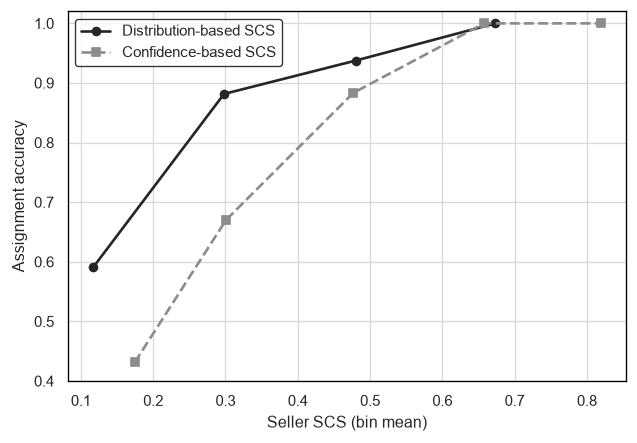

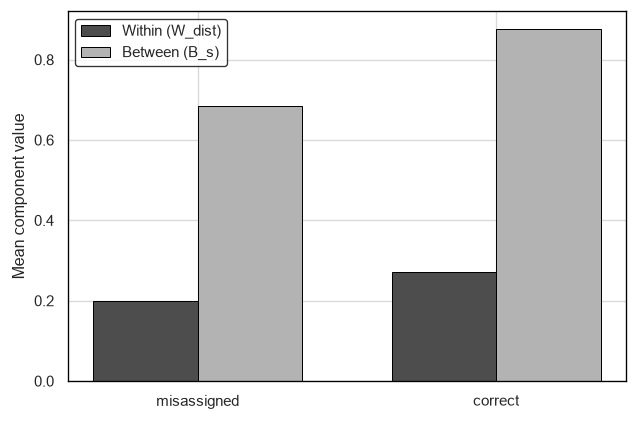

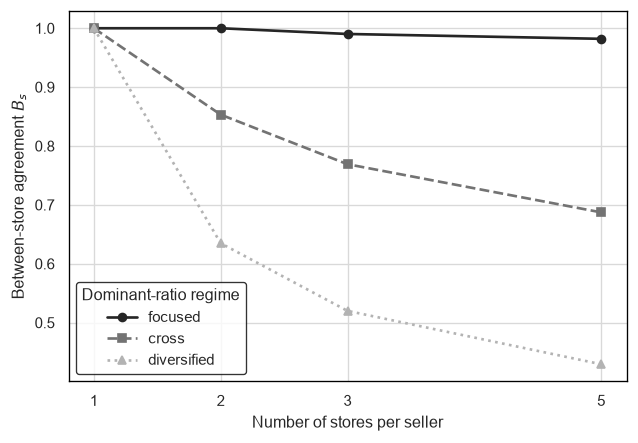

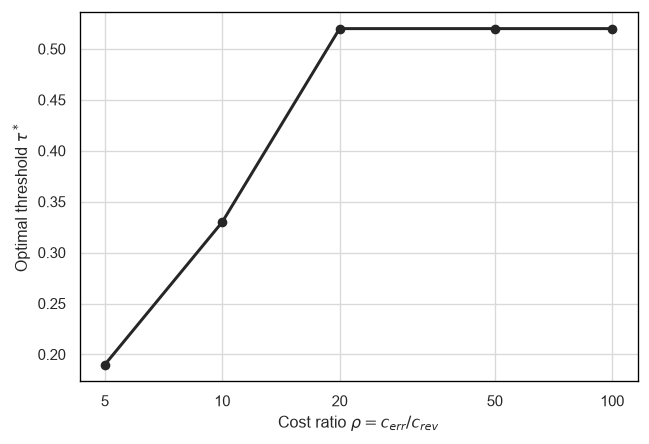

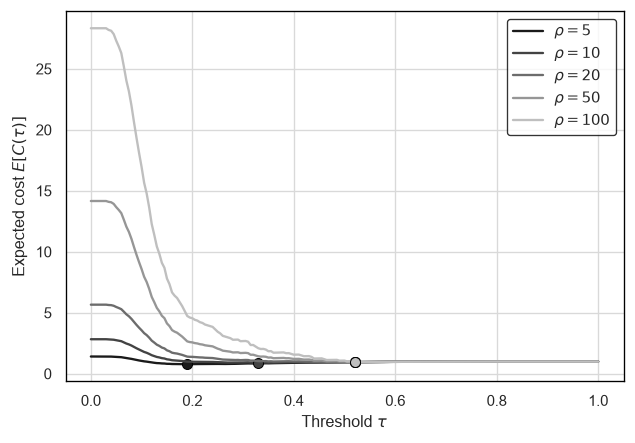

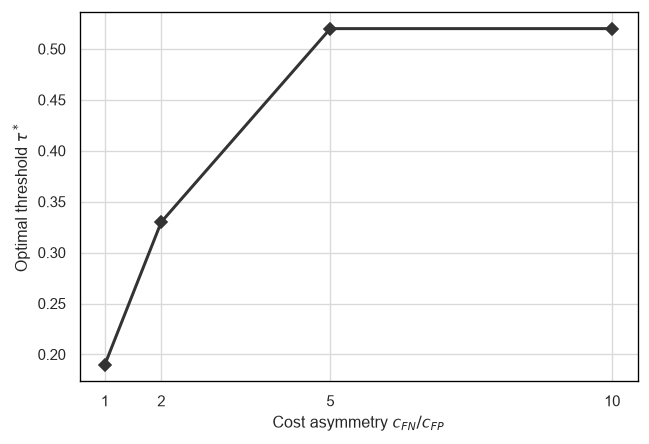

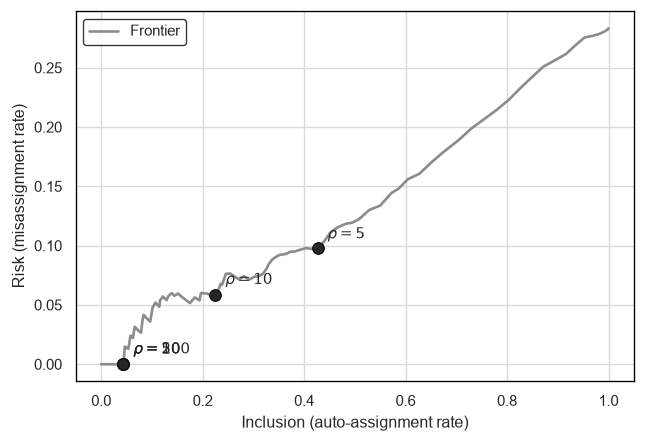

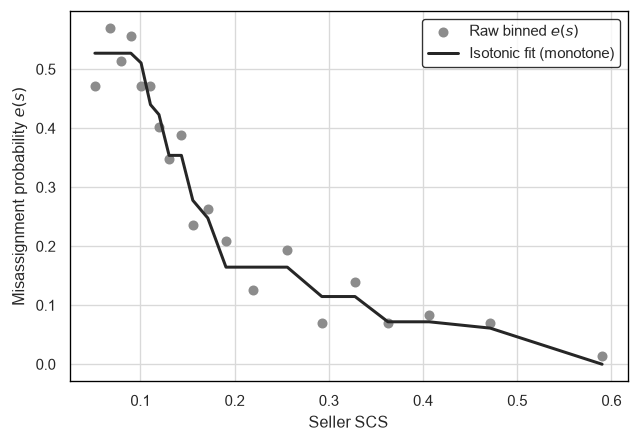

18 figure files written.
  fig1_rq1_scs_monotonicity.pdf
  fig1_rq1_scs_monotonicity.png
  fig2_rq2_within_between.pdf
  fig2_rq2_within_between.png
  fig3_rq2_between_by_regime.pdf
  fig3_rq2_between_by_regime.png
  fig4_rq3_tau_star_curve.pdf
  fig4_rq3_tau_star_curve.png
  fig5_rq3_cost_curves.pdf
  fig5_rq3_cost_curves.png
  fig6_rq3_asymmetric_cost.pdf
  fig6_rq3_asymmetric_cost.png
  fig7_rq4_inclusion_risk_frontier.pdf
  fig7_rq4_inclusion_risk_frontier.png
  fig8_rq3_e_of_s.pdf
  fig8_rq3_e_of_s.png
  fig9_rq1_backend_robustness.pdf
  fig9_rq1_backend_robustness.png


In [2]:
# %% ============================================================
# Notebook 05 — Figures (Grayscale)
# Global figure style: grayscale seaborn, publication settings.
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
ARTIFACT_DIR = os.path.join(ROOT, "artifacts")
TAB_DIR = os.path.join(ROOT, "results", "tables")
FIG_DIR = os.path.join(ROOT, "results", "figures")

sns.set_theme(style="whitegrid", palette="gray", context="paper")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "font.size": 11,
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "grid.color": "0.85",
    "image.cmap": "gray",
})
GRAYS = ["0.15", "0.40", "0.60", "0.80"]


def savefig(fig, name):
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(FIG_DIR, f"{name}.{ext}"),
                    dpi=600, bbox_inches="tight")

# %% ============================================================
# Load all analysis outputs
# ============================================================
scs_df = pd.read_csv(os.path.join(ARTIFACT_DIR, "seller_scs.csv"))
a = scs_df[scs_df["method"] == "A_real"].copy()
a["misassign"] = 1 - a["assign_correct"]
mono_dist = pd.read_csv(os.path.join(TAB_DIR, "table_scs_monotonicity_distribution.csv"))
mono_conf = pd.read_csv(os.path.join(TAB_DIR, "table_scs_monotonicity_confidence.csv"))
tau_star = pd.read_csv(os.path.join(TAB_DIR, "table_tau_star_by_rho.csv"))
cost_curves = pd.read_csv(os.path.join(ARTIFACT_DIR, "tau_cost_curves.csv"))
asym = pd.read_csv(os.path.join(TAB_DIR, "table_tau_asymmetric.csv"))
frontier = pd.read_csv(os.path.join(ARTIFACT_DIR, "inclusion_risk_frontier.csv"))
op_pts = pd.read_csv(os.path.join(TAB_DIR, "table_optimal_operating_points.csv"))
diag = pd.read_csv(os.path.join(TAB_DIR, "table_within_between_diagnosis.csv"))
print("loaded analysis tables")

# %% ============================================================
# Figure 1 (RQ1): SCS bin-level assignment accuracy monotonicity,
# distribution-based vs confidence-based SCS.
# ============================================================
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(mono_dist["mean_scs"], mono_dist["assign_acc"], marker="o",
        color="0.15", linewidth=1.6, label="Distribution-based SCS")
ax.plot(mono_conf["mean_scs"], mono_conf["assign_acc"], marker="s",
        color="0.55", linewidth=1.6, linestyle="--", label="Confidence-based SCS")
ax.set_xlabel("Seller SCS (bin mean)")
ax.set_ylabel("Assignment accuracy")
ax.set_ylim(0.4, 1.02)
ax.legend(frameon=True, edgecolor="black")
savefig(fig, "fig1_rq1_scs_monotonicity")
plt.show()

# %% ============================================================
# Figure 2 (RQ2): within vs between source of misassignment.
# Grouped bars of mean W_dist and mean B_s for correct vs misassigned.
# ============================================================
fig, ax = plt.subplots(figsize=(6, 4))
groups = diag["group"].tolist()
x = np.arange(len(groups))
w = 0.35
ax.bar(x - w/2, diag["mean_W_dist"], w, color="0.30", label="Within (W_dist)",
       edgecolor="black", linewidth=0.6)
ax.bar(x + w/2, diag["mean_B_s"], w, color="0.70", label="Between (B_s)",
       edgecolor="black", linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylabel("Mean component value")
ax.legend(frameon=True, edgecolor="black")
savefig(fig, "fig2_rq2_within_between")
plt.show()

# %% ============================================================
# Figure 3 (RQ2): within/between contribution by dominant-ratio regime.
# Mean B_s (between-store agreement) across regimes and store counts.
# ============================================================
pivot = a.groupby(["regime", "n_stores"])["B_s"].mean().reset_index()
fig, ax = plt.subplots(figsize=(6, 4))
regimes = ["focused", "cross", "diversified"]
styles = [("o", "-", "0.15"), ("s", "--", "0.45"), ("^", ":", "0.70")]
for reg, (mk, ls, col) in zip(regimes, styles):
    sub = pivot[pivot["regime"] == reg]
    ax.plot(sub["n_stores"], sub["B_s"], marker=mk, linestyle=ls,
            color=col, linewidth=1.6, label=reg)
ax.set_xlabel("Number of stores per seller")
ax.set_ylabel("Between-store agreement $B_s$")
ax.set_xticks(sorted(a["n_stores"].unique()))
ax.legend(frameon=True, edgecolor="black", title="Dominant-ratio regime")
savefig(fig, "fig3_rq2_between_by_regime")
plt.show()

# %% ============================================================
# Figure 4 (RQ3): cost-optimal threshold curve tau*(rho).
# ============================================================
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(tau_star["rho"], tau_star["tau_star"], marker="o",
        color="0.15", linewidth=1.8)
ax.set_xscale("log")
ax.set_xlabel(r"Cost ratio $\rho = c_{err}/c_{rev}$")
ax.set_ylabel(r"Optimal threshold $\tau^*$")
ax.set_xticks(tau_star["rho"])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
savefig(fig, "fig4_rq3_tau_star_curve")
plt.show()

# %% ============================================================
# Figure 5 (RQ3): expected-cost curves E[C(tau)] for several rho,
# with the optimal tau* marked on each.
# ============================================================
fig, ax = plt.subplots(figsize=(6, 4))
rhos = sorted(cost_curves["rho"].unique())
grays = np.linspace(0.1, 0.75, len(rhos))
for rho, gg in zip(rhos, grays):
    sub = cost_curves[cost_curves["rho"] == rho]
    ax.plot(sub["tau_grid"], sub["cost"], color=str(gg), linewidth=1.4,
            label=fr"$\rho={rho}$")
    ts = float(tau_star[tau_star["rho"] == rho]["tau_star"].iloc[0])
    tc = sub[np.isclose(sub["tau_grid"], ts)]["cost"]
    if len(tc):
        ax.plot(ts, tc.iloc[0], marker="o", color=str(gg), markersize=6,
                markeredgecolor="black", markeredgewidth=0.6)
ax.set_xlabel(r"Threshold $\tau$")
ax.set_ylabel(r"Expected cost $E[C(\tau)]$")
ax.legend(frameon=True, edgecolor="black")
savefig(fig, "fig5_rq3_cost_curves")
plt.show()

# %% ============================================================
# Figure 6 (RQ3): tau* shift under FN/FP cost asymmetry.
# ============================================================
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(asym["c_fn_over_c_fp"], asym["tau_star"], marker="D",
        color="0.20", linewidth=1.8)
ax.set_xlabel(r"Cost asymmetry $c_{FN}/c_{FP}$")
ax.set_ylabel(r"Optimal threshold $\tau^*$")
ax.set_xticks(asym["c_fn_over_c_fp"])
savefig(fig, "fig6_rq3_asymmetric_cost")
plt.show()

# %% ============================================================
# Figure 7 (RQ4): inclusion-risk frontier with optimal operating
# points marked for each cost ratio rho.
# ============================================================
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(frontier["inclusion"], frontier["risk"], color="0.55",
        linewidth=1.6, label="Frontier")
for _, r in op_pts.iterrows():
    ax.plot(r["inclusion"], r["risk"], marker="o", color="0.15",
            markersize=7, markeredgecolor="black", markeredgewidth=0.6)
    ax.annotate(fr"$\rho={int(r['rho'])}$", (r["inclusion"], r["risk"]),
                textcoords="offset points", xytext=(6, 6), fontsize=9)
ax.set_xlabel("Inclusion (auto-assignment rate)")
ax.set_ylabel("Risk (misassignment rate)")
ax.legend(frameon=True, edgecolor="black")
savefig(fig, "fig7_rq4_inclusion_risk_frontier")
plt.show()

# %% ============================================================
# Figure 8 (RQ3 support): SCS-conditional misassignment e(s):
# raw binned estimate (points) plus the isotonic monotone fit (line)
# that guarantees tau* uniqueness.
# ============================================================
ecurve = pd.read_csv(os.path.join(ARTIFACT_DIR, "e_of_s_curve.csv"))
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ecurve["scs_mid"], ecurve["e_s"], marker="o", linestyle="none",
        color="0.55", markersize=5, label="Raw binned $e(s)$")
ax.plot(ecurve["scs_mid"], ecurve["e_s_iso"], color="0.15",
        linewidth=1.8, label="Isotonic fit (monotone)")
ax.set_xlabel("Seller SCS")
ax.set_ylabel(r"Misassignment probability $e(s)$")
ax.legend(frameon=True, edgecolor="black")
savefig(fig, "fig8_rq3_e_of_s")
plt.show()

# %% ============================================================
# List all saved figures
# ============================================================
figs = sorted(f for f in os.listdir(FIG_DIR) if f.endswith((".png", ".pdf")))
print(f"{len(figs)} figure files written.")
for f in figs:
    print(" ", f)